# 🌿 Classificador de Doenças em Plantas com I.A.

## Descrição
Este projeto utiliza **Visão Computacional** e **Transfer Learning**
para identificar doenças em folhas de plantas a partir de imagens.

## Tecnologias utilizadas
- Python
- TensorFlow / Keras
- MobileNetV2 (Transfer Learning)
- Google Colab (GPU T4)

## Dataset
New Plant Diseases Dataset — mais de 87.000 imagens de 38 classes diferentes

In [1]:
# Instalando as bibliotecas necessárias
# Bibliotecas são "caixas de ferramentas" prontas que outras pessoas criaram
# para não precisarmos escrever tudo do zero

!pip install tensorflow matplotlib numpy pillow -q

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_set_from_installed()
              

## Etapa 1 — Configuração e Download dos Dados

In [2]:
# Conectando o Google Drive ao Colab
# O Drive vai funcionar como nosso "HD externo" para guardar os dados
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Baixando o dataset direto do Kaggle para o servidor do Google
# Isso é muito mais rápido do que baixar no seu PC e depois enviar

import kagglehub

# Esse comando vai até o Kaggle e baixa as imagens automaticamente
caminho = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

# Mostra onde as imagens foram salvas
print("Imagens salvas em:", caminho)

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Imagens salvas em: /kaggle/input/new-plant-diseases-dataset


In [4]:
import os

# Definindo o caminho onde estão as imagens de treino
# "treino" = fotos que a I.A. vai usar para aprender
caminho_treino = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"

# Listando todas as "pastas de doenças" que existem
# Cada pasta tem o nome de uma doença e contém fotos daquela doença
doencas = sorted(os.listdir(caminho_treino))

# Mostrando quantas doenças existem e quais são
print(f"Total de categorias: {len(doencas)}")
print("\nLista de doenças/categorias:")
for i, doenca in enumerate(doencas):
    print(f"  {i+1}. {doenca}")

Total de categorias: 38

Lista de doenças/categorias:
  1. Apple___Apple_scab
  2. Apple___Black_rot
  3. Apple___Cedar_apple_rust
  4. Apple___healthy
  5. Blueberry___healthy
  6. Cherry_(including_sour)___Powdery_mildew
  7. Cherry_(including_sour)___healthy
  8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
  9. Corn_(maize)___Common_rust_
  10. Corn_(maize)___Northern_Leaf_Blight
  11. Corn_(maize)___healthy
  12. Grape___Black_rot
  13. Grape___Esca_(Black_Measles)
  14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
  15. Grape___healthy
  16. Orange___Haunglongbing_(Citrus_greening)
  17. Peach___Bacterial_spot
  18. Peach___healthy
  19. Pepper,_bell___Bacterial_spot
  20. Pepper,_bell___healthy
  21. Potato___Early_blight
  22. Potato___Late_blight
  23. Potato___healthy
  24. Raspberry___healthy
  25. Soybean___healthy
  26. Squash___Powdery_mildew
  27. Strawberry___Leaf_scorch
  28. Strawberry___healthy
  29. Tomato___Bacterial_spot
  30. Tomato___Early_blight
  31. Tomat

## Etapa 2 — Análise Exploratória dos Dados

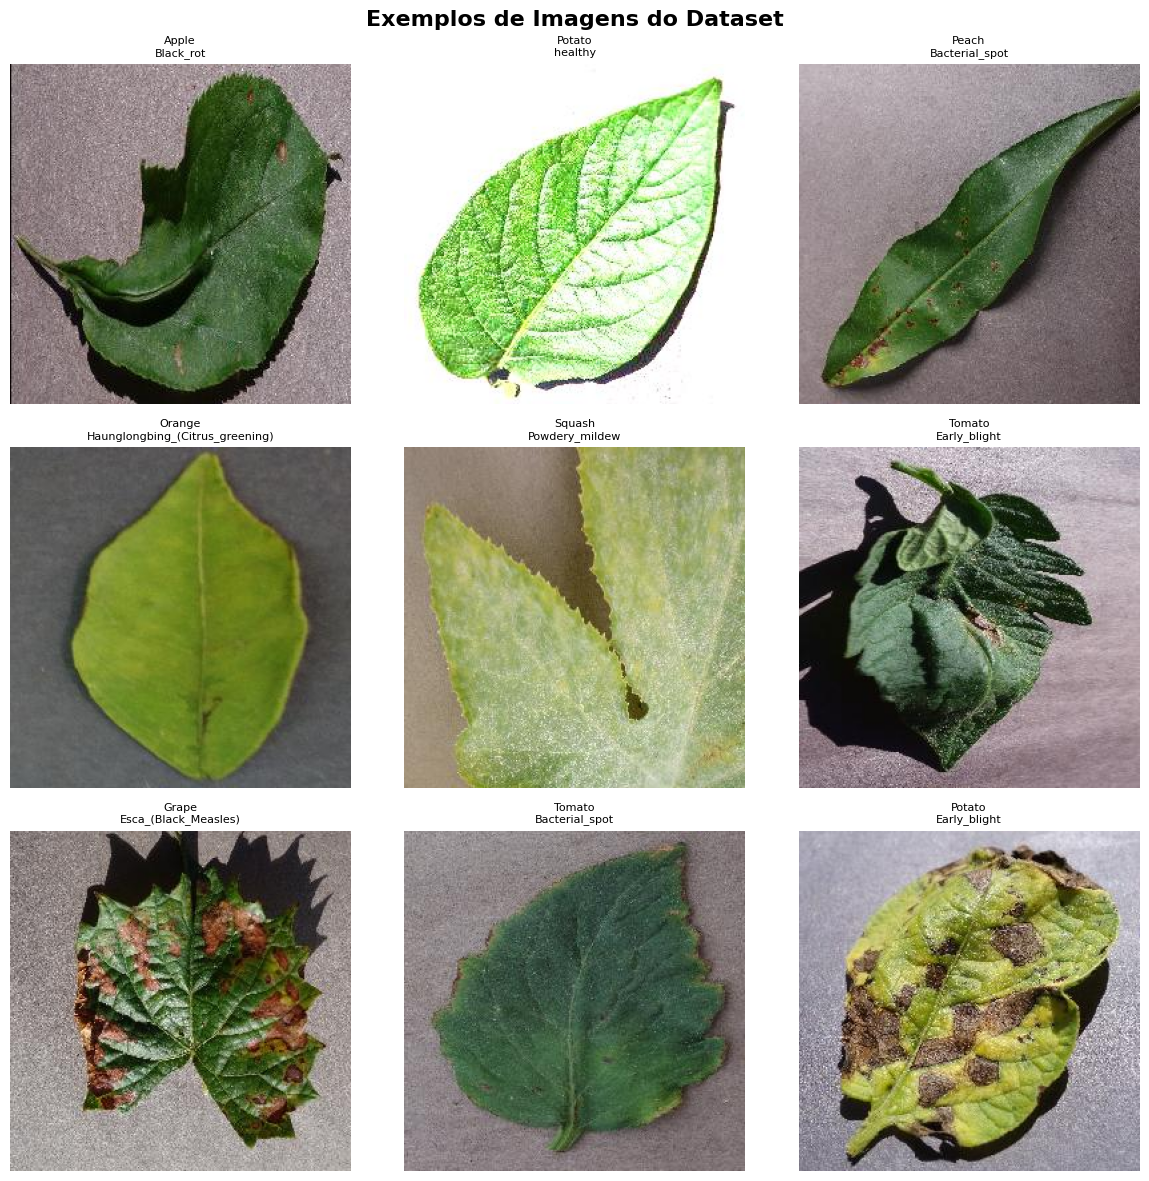

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Escolhendo 9 doenças aleatórias para mostrar como exemplo
doencas_exemplo = random.sample(doencas, 9)

# Criando uma grade de imagens 3x3
fig, eixos = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle("Exemplos de Imagens do Dataset", fontsize=16, fontweight='bold')

# Percorrendo cada doença escolhida e mostrando uma foto
for i, eixo in enumerate(eixos.flat):
    # Entrando na pasta da doença
    pasta_doenca = os.path.join(caminho_treino, doencas_exemplo[i])

    # Escolhendo uma foto aleatória dessa doença
    foto_aleatoria = random.choice(os.listdir(pasta_doenca))

    # Abrindo a foto
    caminho_foto = os.path.join(pasta_doenca, foto_aleatoria)
    imagem = Image.open(caminho_foto)

    # Mostrando a foto com o nome da doença embaixo
    eixo.imshow(imagem)
    eixo.set_title(doencas_exemplo[i].replace("___", "\n"), fontsize=8)
    eixo.axis('off')  # Remove os eixos numéricos

plt.tight_layout()
plt.show()

In [6]:
# Contando quantas fotos existem em cada categoria
print("Quantidade de imagens por categoria:\n")

total_imagens = 0

for doenca in doencas:
    pasta = os.path.join(caminho_treino, doenca)
    quantidade = len(os.listdir(pasta))
    total_imagens += quantidade
    print(f"  {doenca}: {quantidade} imagens")

print(f"\nTotal geral: {total_imagens} imagens de treino")

Quantidade de imagens por categoria:

  Apple___Apple_scab: 2016 imagens
  Apple___Black_rot: 1987 imagens
  Apple___Cedar_apple_rust: 1760 imagens
  Apple___healthy: 2008 imagens
  Blueberry___healthy: 1816 imagens
  Cherry_(including_sour)___Powdery_mildew: 1683 imagens
  Cherry_(including_sour)___healthy: 1826 imagens
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1642 imagens
  Corn_(maize)___Common_rust_: 1907 imagens
  Corn_(maize)___Northern_Leaf_Blight: 1908 imagens
  Corn_(maize)___healthy: 1859 imagens
  Grape___Black_rot: 1888 imagens
  Grape___Esca_(Black_Measles): 1920 imagens
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1722 imagens
  Grape___healthy: 1692 imagens
  Orange___Haunglongbing_(Citrus_greening): 2010 imagens
  Peach___Bacterial_spot: 1838 imagens
  Peach___healthy: 1728 imagens
  Pepper,_bell___Bacterial_spot: 1913 imagens
  Pepper,_bell___healthy: 1988 imagens
  Potato___Early_blight: 1939 imagens
  Potato___Late_blight: 1939 imagens
  Potato___health

## Etapa 3 — Pré-processamento dos Dados

In [7]:
import tensorflow as tf

# Definindo o tamanho padrão que todas as imagens vão ter
# 224x224 pixels é o tamanho que o MobileNetV2 espera receber
TAMANHO_IMAGEM = (224, 224)

# Quantas imagens vamos processar ao mesmo tempo
# Pensa como uma esteira de fábrica — processa 32 fotos por vez
TAMANHO_LOTE = 32

# Caminho da pasta de validação
# Validação = fotos que a I.A. NUNCA viu, usadas para testar se ela aprendeu
caminho_validacao = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

# Carregando as imagens de treino
# flow_from_directory = lê as imagens direto das pastas automaticamente
dados_treino = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255  # Transforma os pixels de 0-255 para 0-1 (a I.A. aprende melhor assim)
).flow_from_directory(
    caminho_treino,
    target_size=TAMANHO_IMAGEM,  # Redimensiona todas para 224x224
    batch_size=TAMANHO_LOTE,     # Processa 32 por vez
    class_mode='categorical'     # Modo de classificação com várias categorias
)

# Carregando as imagens de validação (para testar a I.A.)
dados_validacao = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    caminho_validacao,
    target_size=TAMANHO_IMAGEM,
    batch_size=TAMANHO_LOTE,
    class_mode='categorical'
)

print("✅ Dados preparados com sucesso!")
print(f"Classes encontradas: {len(dados_treino.class_indices)}")

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
✅ Dados preparados com sucesso!
Classes encontradas: 38


## Etapa 4 — Construção do Modelo

In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Carregando o MobileNetV2 — modelo já treinado pelo Google
# include_top=False = traz só o "cérebro" do modelo, sem a parte final
# weights='imagenet' = já vem com o conhecimento de 1 milhão de imagens
base_model = MobileNetV2(
    input_shape=(224, 224, 3),  # 224x224 pixels, 3 canais de cor (RGB)
    include_top=False,
    weights='imagenet'
)

# Congelando o modelo base
# Isso significa: "não mude o que você já sabe, só aprenda a parte nova"
# Como dizer ao motorista experiente: "não esqueça como dirigir, só aprenda o caminhão"
base_model.trainable = False

# Construindo o modelo completo
modelo = models.Sequential([
    base_model,                          # O cérebro que já sabe reconhecer imagens
    layers.GlobalAveragePooling2D(),     # Resume as informações encontradas
    layers.Dense(128, activation='relu'), # Camada de raciocínio com 128 neurônios
    layers.Dropout(0.2),                 # Desliga 20% dos neurônios aleatoriamente (evita decoreba)
    layers.Dense(38, activation='softmax') # Camada final: 1 saída para cada doença
])

# Compilando o modelo
# Aqui definimos COMO a I.A. vai aprender
modelo.compile(
    optimizer='adam',           # Algoritmo que ajusta o aprendizado automaticamente
    loss='categorical_crossentropy', # Forma de medir o erro da I.A.
    metrics=['accuracy']        # Vamos acompanhar a porcentagem de acerto
)

# Mostrando um resumo do modelo
modelo.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,854 (9.26 MB)

 Trainable params: 168,870 (659.65 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Etapa 5 — Treinamento do Modelo

In [9]:
# Treinando o modelo!
# epochs=5 significa que a I.A. vai ver TODAS as imagens 5 vezes
# Cada vez que vê tudo, ela aprende um pouco mais — como reler um livro
historico = modelo.fit(
    dados_treino,        # As fotos de treino
    epochs=5,            # Número de vezes que vai estudar tudo
    validation_data=dados_validacao,  # Fotos para testar o aprendizado
    verbose=1            # Mostra o progresso na tela
)

print("\n✅ Treinamento concluído!")

Epoch 1/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4506s 2s/step - accuracy: 0.8583 - loss: 0.4631 - val_accuracy: 0.9300 - val_loss: 0.2127
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4510s 2s/step - accuracy: 0.9272 - loss: 0.2161 - val_accuracy: 0.9491 - val_loss: 0.1530
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4748s 2s/step - accuracy: 0.9409 - loss: 0.1728 - val_accuracy: 0.9516 - val_loss: 0.1492
Epoch 4/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4473s 2s/step - accuracy: 0.9486 - loss: 0.1484 - val_accuracy: 0.9557 - val_loss: 0.1282
Epoch 5/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4405s 2s/step - accuracy: 0.9550 - loss: 0.1269 - val_accuracy: 0.9542 - val_loss: 0.1387

✅ Treinamento concluído!


## Etapa 6 — Avaliação do Modelo

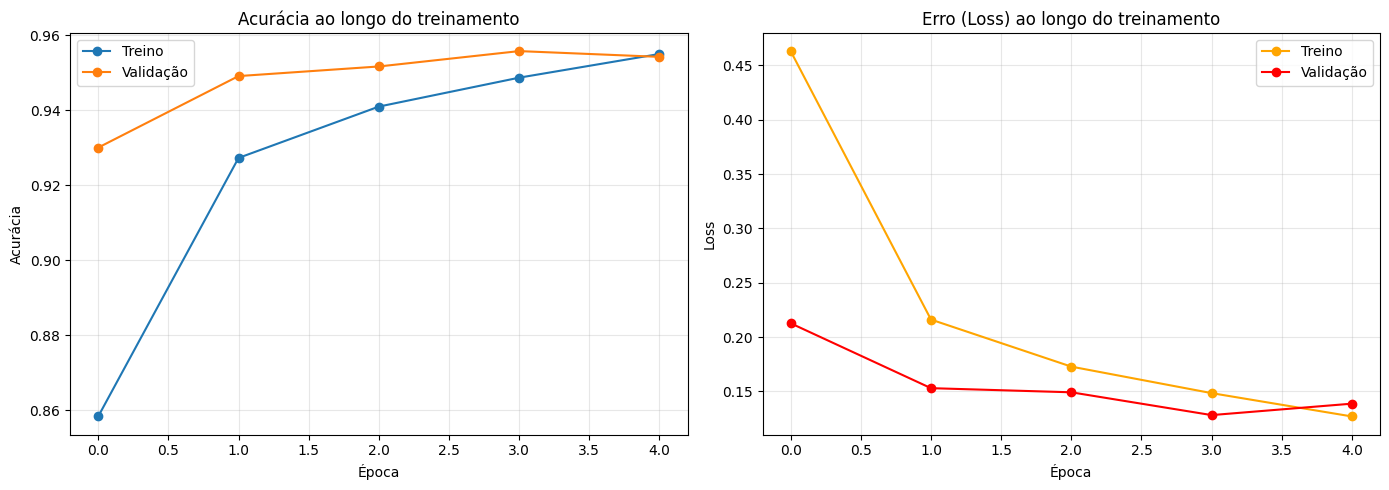

In [10]:
import matplotlib.pyplot as plt

# Criando uma figura com dois gráficos lado a lado
fig, (grafico1, grafico2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Evolução da acurácia (taxa de acerto)
grafico1.plot(historico.history['accuracy'], label='Treino', marker='o')
grafico1.plot(historico.history['val_accuracy'], label='Validação', marker='o')
grafico1.set_title('Acurácia ao longo do treinamento')
grafico1.set_xlabel('Época')
grafico1.set_ylabel('Acurácia')
grafico1.legend()
grafico1.grid(True, alpha=0.3)

# Gráfico 2: Evolução do erro (loss)
grafico2.plot(historico.history['loss'], label='Treino', marker='o', color='orange')
grafico2.plot(historico.history['val_loss'], label='Validação', marker='o', color='red')
grafico2.set_title('Erro (Loss) ao longo do treinamento')
grafico2.set_xlabel('Época')
grafico2.set_ylabel('Loss')
grafico2.legend()
grafico2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evolucao_treinamento.png', dpi=150)  # Salva a imagem em arquivo
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


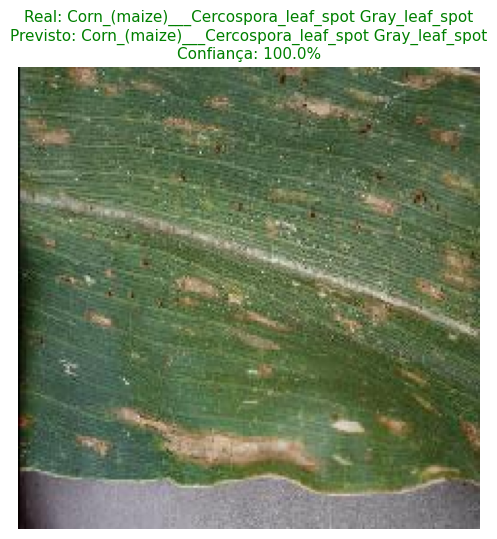

In [13]:
import numpy as np

# Pegando os nomes das classes na ordem certa
nomes_classes = list(dados_treino.class_indices.keys())

# Escolhendo uma foto aleatória da validação para testar
doenca_teste = random.choice(doencas)
pasta_teste = os.path.join(caminho_validacao, doenca_teste)
foto_teste = random.choice(os.listdir(pasta_teste))
caminho_foto_teste = os.path.join(pasta_teste, foto_teste)

# Carregando e preparando a imagem da mesma forma que no treino
imagem_teste = tf.keras.preprocessing.image.load_img(caminho_foto_teste, target_size=(224, 224))
imagem_array = tf.keras.preprocessing.image.img_to_array(imagem_teste) / 255.0
imagem_array = np.expand_dims(imagem_array, axis=0)  # Adiciona uma dimensão extra (a I.A. espera um "lote", mesmo que seja 1 foto)

# Fazendo a previsão
previsao = modelo.predict(imagem_array)
classe_prevista = nomes_classes[np.argmax(previsao)]
confianca = np.max(previsao) * 100

# Mostrando o resultado visualmente
plt.figure(figsize=(6, 6))
plt.imshow(imagem_teste)
plt.axis('off')
cor_titulo = 'green' if classe_prevista == doenca_teste else 'red'
plt.title(
    f"Real: {doenca_teste}\nPrevisto: {classe_prevista}\nConfiança: {confianca:.1f}%",
    color=cor_titulo, fontsize=11
)
plt.show()

## Etapa 7 — Salvando o Modelo Treinado

In [14]:
# Salvando o modelo treinado em um arquivo
# Isso é como salvar o "cérebro" da I.A. para usar depois sem precisar treinar de novo
modelo.save('classificador_doencas_plantas.keras')

print("✅ Modelo salvo com sucesso!")
print("Arquivo: classificador_doencas_plantas.keras")

# Verificando o tamanho do arquivo salvo
tamanho_mb = os.path.getsize('classificador_doencas_plantas.keras') / (1024 * 1024)
print(f"Tamanho do arquivo: {tamanho_mb:.2f} MB")

✅ Modelo salvo com sucesso!
Arquivo: classificador_doencas_plantas.keras
Tamanho do arquivo: 11.11 MB
